# Variable-Energy Doppler Broadening (VEDB) Lineshape Analysis

VEDB measures the S and W lineshape parameters as a function of positron **beam energy** E. By varying E, positrons are implanted at different mean depths — lower energy means shallower implantation. The resulting S(E) and W(E) curves reveal the depth profile of open-volume defects and their chemical environment.

## Interpreting S(E) and W(E)

- **S(E) rising** toward the surface → higher defect density (more vacancies) near the surface.
- **S(E) saturating** at high energy → the bulk reference value; all positrons reach defect-free bulk.
- **W(E) falling** as S(E) rises → anti-correlated because both are fractions of the same peak area.
- **S–W parametric plot** (S vs. W at each energy): a straight-line trajectory through the bulk and surface reference points is consistent with a single defect type; deviations indicate multiple defect species or chemical changes with depth.

## Workflow

1. Set up detector calibration
2. Load one DB spectrum per beam energy and create `PASdb` objects
3. Compute S(E) with `compute_s_lineshape`
4. Compute W(E) with `compute_w_lineshape`
5. Plot S(E) and W(E) curves
6. Inspect the S–W parametric plot

In [2]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import nominal_value, std_dev
from scispectrum.calibration import AxisCalibration, ResolutionCalibration
from scispectrum.io import TimeChannelParser
from pypas.core import PASdb
from pypas.analysis import compute_s_lineshape, compute_w_lineshape

## 1. Detector calibration

All spectra in a VEDB series must use the **same** energy calibration and resolution model, so that S and W windows are defined consistently across energies (although PASdb.recenter() function can fix small deviationas).

> **Adapt to your detector:** replace the polynomial coefficients and FWHM below.

In [3]:
# ── Adapt to your detector ────────────────────────────────────────────────────
data_dir               = '../libs/cu_sample_500/detector_0'
energy_calib_poly      = np.poly1d([0.0408976444, 0.0822321508])  # channel → keV
energy_resolution_fwhm = 1.05   # FWHM at 511 keV [keV]
# ─────────────────────────────────────────────────────────────────────────────

axis_calibration = AxisCalibration(energy_calib_poly, name='energy')
resolution_calibration = ResolutionCalibration(
    lambda energy: energy_resolution_fwhm * (energy / 511) ** 0.5)

## 2. Load spectra at all beam energies

Each file corresponds to one positron beam energy. The beam energy is parsed from the filename (e.g. `3500eV_ch000.txt` → 3.5 keV). Files are loaded in ascending energy order.

`centralize_peak=True` shifts each spectrum's axis calibration so the detected 511 keV peak centre aligns exactly with the electron rest mass energy — this is essential for consistent window placement across spectra taken at different times or with slight gain drift.

> **Adapt the filename pattern** if your files use a different naming convention. The key requirement is that beam energy in keV can be extracted from each filename.

In [4]:
# Collect files and parse beam energies from filenames
files = sorted(
    glob.glob(os.path.join(data_dir, '*.txt')),
    key=lambda f: int(os.path.basename(f).replace('eV_ch000.txt', ''))
)

energies    = []   # beam energies [keV]
db_spectra  = []   # one PASdb per energy

for f in files:
    ev = int(os.path.basename(f).replace('eV_ch000.txt', ''))
    data = pd.read_csv(f, skiprows=5, sep=' ',
                       names=['time', 'channel', 'flag'], usecols=range(3))
    spectrum = TimeChannelParser.from_dataframe(data, axis_calibration, resolution_calibration)
    db = PASdb.from_spectrum(spectrum, centralize_peak=True)
    energies.append(ev / 1000)   # eV → keV
    db_spectra.append(db)

print(f'Loaded {len(db_spectra)} spectra')
print(f'Beam energies: {energies} keV')

Loaded 16 spectra
Beam energies: [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0] keV


## 3. Compute S(E)

`compute_s_lineshape` iterates over the list of `PASdb` objects and calls `s_parameter_calculation` on each, returning a `pd.Series` of `ufloat` values indexed by beam energy.

Setting `centralize=False` here because each spectrum was already centred during loading (`centralize_peak=True` above).

> **Adapt window boundaries** to your detector resolution and material system.

In [5]:
# ── Adapt window boundaries to your measurement ──────────────────────────────
total_energy_domain = [507.7, 514.9]  # full integration range [keV]
energy_domain_s     = [510.2, 511.8]  # S window — central low-momentum region [keV]
# ─────────────────────────────────────────────────────────────────────────────

s_series = compute_s_lineshape(
    db_spectra, energies,
    energy_domain_total=total_energy_domain,
    energy_domain_s=energy_domain_s,
    centralize=False,   # already centred during loading
)

print('S(E):')
print(s_series.to_string())

S(E):
energy
0.5    0.4965+/-0.0007
1.0    0.4949+/-0.0007
1.5    0.4940+/-0.0007
2.0    0.4931+/-0.0007
2.5    0.4922+/-0.0006
3.0    0.4924+/-0.0006
3.5    0.4910+/-0.0006
4.0    0.4901+/-0.0006
4.5    0.4883+/-0.0006
5.0    0.4877+/-0.0007
5.5    0.4853+/-0.0007
6.0    0.4838+/-0.0007
6.5    0.4844+/-0.0007
7.0    0.4853+/-0.0007
7.5    0.4830+/-0.0006
8.0    0.4829+/-0.0007


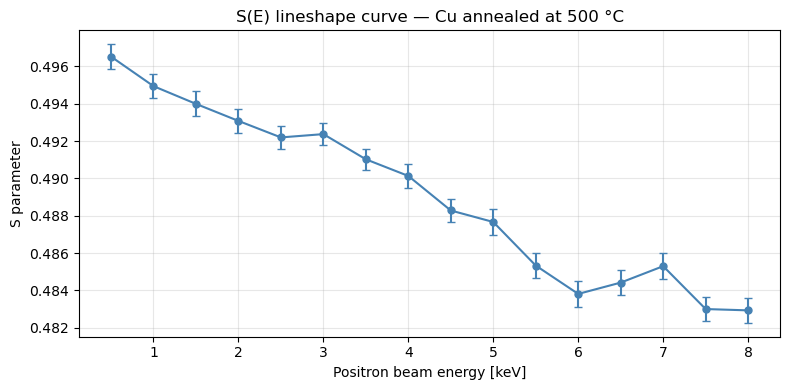

In [6]:
s_vals = np.array([nominal_value(v) for v in s_series])
s_errs = np.array([std_dev(v)       for v in s_series])

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(s_series.index, s_vals, yerr=s_errs,
            fmt='o-', capsize=3, color='steelblue', lw=1.5, markersize=5)
ax.set_xlabel('Positron beam energy [keV]')
ax.set_ylabel('S parameter')
ax.set_title('S(E) lineshape curve — Cu annealed at 500 °C')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Compute W(E)

`compute_w_lineshape` works identically to `compute_s_lineshape` but requires left and right wing window boundaries in addition to the total domain.

> **Adapt `energy_domain_w_l` and `energy_domain_w_r`** to your measurement. Windows must lie within the total domain and outside the S window.

In [7]:
# ── Adapt W window boundaries ─────────────────────────────────────────────────
energy_domain_w_l = [507.8, 509.3]  # W window — left wing [keV]
energy_domain_w_r = [512.7, 514.8]  # W window — right wing [keV]
# ─────────────────────────────────────────────────────────────────────────────

w_series = compute_w_lineshape(
    db_spectra, energies,
    energy_domain_total=total_energy_domain,
    energy_domain_w_left=energy_domain_w_l,
    energy_domain_w_right=energy_domain_w_r,
    centralize=False,
)

print('W(E):')
print(w_series.to_string())

W(E):
energy
0.5    0.1656+/-0.0005
1.0    0.1666+/-0.0005
1.5    0.1685+/-0.0005
2.0    0.1692+/-0.0005
2.5    0.1703+/-0.0005
3.0    0.1710+/-0.0005
3.5    0.1724+/-0.0004
4.0    0.1742+/-0.0005
4.5    0.1761+/-0.0005
5.0    0.1766+/-0.0005
5.5    0.1782+/-0.0005
6.0    0.1802+/-0.0005
6.5    0.1802+/-0.0005
7.0    0.1804+/-0.0005
7.5    0.1834+/-0.0005
8.0    0.1823+/-0.0005


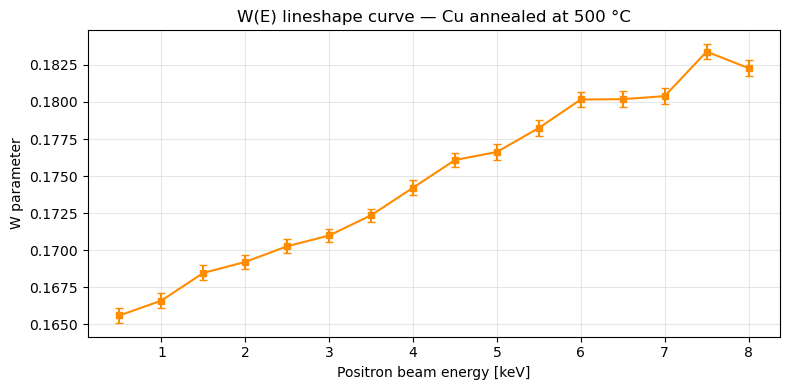

In [8]:
w_vals = np.array([nominal_value(v) for v in w_series])
w_errs = np.array([std_dev(v)       for v in w_series])

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(w_series.index, w_vals, yerr=w_errs,
            fmt='s-', capsize=3, color='darkorange', lw=1.5, markersize=5)
ax.set_xlabel('Positron beam energy [keV]')
ax.set_ylabel('W parameter')
ax.set_title('W(E) lineshape curve — Cu annealed at 500 °C')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. S and W on a shared axis

Plotting S and W together on a dual y-axis makes the anti-correlation between them immediately visible: as S increases toward the surface (lower energy), W decreases, and vice versa.

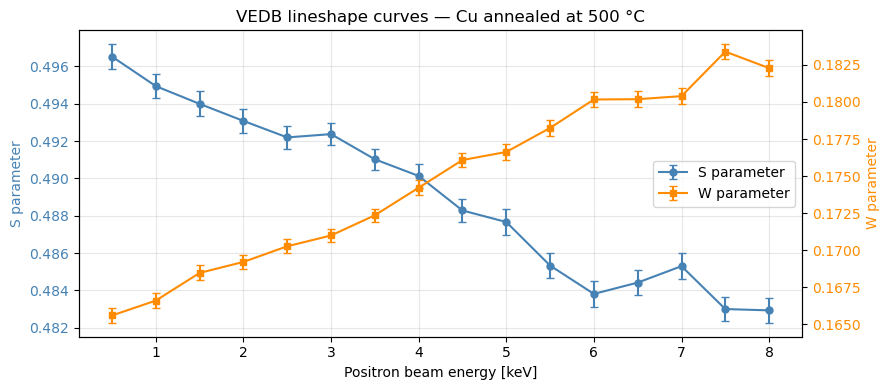

In [9]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

l1 = ax1.errorbar(s_series.index, s_vals, yerr=s_errs,
                  fmt='o-', capsize=3, color='steelblue',
                  lw=1.5, markersize=5, label='S parameter')
l2 = ax2.errorbar(w_series.index, w_vals, yerr=w_errs,
                  fmt='s-', capsize=3, color='darkorange',
                  lw=1.5, markersize=5, label='W parameter')

ax1.set_xlabel('Positron beam energy [keV]')
ax1.set_ylabel('S parameter', color='steelblue')
ax2.set_ylabel('W parameter', color='darkorange')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax1.set_title('VEDB lineshape curves — Cu annealed at 500 °C')
ax1.grid(True, alpha=0.3)

lines = [l1, l2]
ax1.legend(lines, [l.get_label() for l in lines], loc='center right')
plt.tight_layout()
plt.show()

## 6. S–W parametric plot

Plotting S against W — with beam energy as the implicit parameter — gives a **chemical fingerprint** of the depth-dependent defect structure.

- Points at **high energy** (deep implantation) cluster near the bulk reference (low S, high W).
- Points at **low energy** (near-surface) scatter toward the surface reference.
- If all points lie on a **single straight line** connecting bulk and surface references, the defect structure is consistent with one dominant defect type throughout the depth profile.
- **Deviations from linearity** indicate multiple defect types or a composition change with depth.

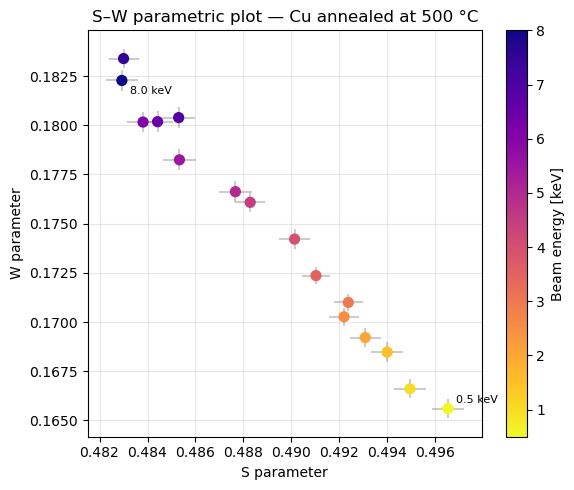

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))

sc = ax.scatter(s_vals, w_vals, c=s_series.index, cmap='plasma_r',
                s=50, zorder=3)
ax.errorbar(s_vals, w_vals, xerr=s_errs, yerr=w_errs,
            fmt='none', color='gray', alpha=0.4, zorder=2)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Beam energy [keV]')

# Annotate lowest and highest energy points
ax.annotate(f'{s_series.index[0]:.1f} keV', (s_vals[0], w_vals[0]),
            textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.annotate(f'{s_series.index[-1]:.1f} keV', (s_vals[-1], w_vals[-1]),
            textcoords='offset points', xytext=(6, -10), fontsize=8)

ax.set_xlabel('S parameter')
ax.set_ylabel('W parameter')
ax.set_title('S–W parametric plot — Cu annealed at 500 °C')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()